# Audio as an Optical Field: Fourier-Derived Images for Music Genre Classification

This notebook presents a complete computational-optics pipeline from labeled audio to generated images and measured genre-classification results. The central idea is to treat short-time Fourier transform (STFT) coefficients as a complex field $E(t, f)$ over time and frequency, then simulate an optical measurement by forming the intensity of a transformed field.

## Research goals
1. Transform audio clips into visually meaningful, optics-inspired images using discrete Fourier analysis.
2. Train a genre classifier on those transformed images and compare multiple image representations.
3. Measure which representation preserves the most genre-discriminative structure.

## Experimental framing
Given audio $x[n]$, the notebook computes an STFT and interprets its complex coefficients as a field $E(t, f)$. A two-dimensional Fourier transform of that field yields an intensity distribution

$$
I = \left|\mathcal{F}_2\{E\}\right|^2,
$$

which plays the role of a camera measurement. The project compares three related image constructions:
- a Cartesian optics intensity image,
- a radial remapping of the same field, and
- a baseline magnitude spectrogram image.

The full workflow is reproducible: the notebook downloads the dataset, caches intermediate products, trains the neural classifier, and writes a final run summary.

## Pipeline

**Inputs**
- The local sample file `TestAudio2.mp3` for transform demonstration.
- The GTZAN labeled genre dataset for supervised evaluation.

**Outputs**
- Publication-ready figures showing waveform, spectrogram, optical intensity maps, and radial remappings.
- A cached image dataset for all tested representations.
- Held-out neural-network evaluation metrics and figures.

**Edge cases accounted for**
- Dataset download and archive extraction.
- Stereo or variable-length audio.
- Numerical issues during decibel conversion.
- Corrupted dataset files, which are logged and skipped.

In [4]:
from __future__ import annotations

import json
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path

import joblib
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import soundfile as sf
from PIL import Image
from scipy.interpolate import RegularGridInterpolator
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupShuffleSplit
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(context='talk', style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['savefig.dpi'] = 180

ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
CACHE_DIR = ROOT / 'cache'
OUTPUT_DIR = ROOT / 'outputs'
FIG_DIR = ROOT / 'figures'
MODEL_DIR = ROOT / 'models'
for path in [DATA_DIR, RAW_DIR, CACHE_DIR, OUTPUT_DIR, FIG_DIR, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

SEED = 42
RNG = np.random.default_rng(SEED)
EPS = 1e-10
XTICKS = np.array([31.25, 62.5, 125, 250, 500, 1000, 2000, 4000, 8000])
XTICK_LABELS = ['31.25', '62.5', '125', '250', '500', '1k', '2k', '4k', '8k']

GTZAN_URL = 'https://huggingface.co/datasets/marsyas/gtzan/resolve/main/data/genres.tar.gz?download=true'
GTZAN_ARCHIVE = RAW_DIR / 'genres.tar.gz'
GTZAN_EXTRACTED = RAW_DIR / 'genres'
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

print('Project root:', ROOT)
print('Data directory:', DATA_DIR)

Project root: c:\Users\Calvin\Desktop\computionalopticsfourier
Data directory: c:\Users\Calvin\Desktop\computionalopticsfourier\data


## Dataset acquisition

The supervised experiment uses the GTZAN dataset: 1,000 audio clips distributed across 10 genres. The code below downloads the public archive, extracts the audio files, and prepares them for the image-generation pipeline.

In [21]:
def download_file(url: str, destination: Path, chunk_size: int = 2**20) -> Path:
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.exists():
        print(f'Using cached file: {destination}')
        return destination

    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()
    total = int(response.headers.get('Content-Length', 0))
    with destination.open('wb') as handle, tqdm(total=total, unit='B', unit_scale=True, desc=destination.name) as progress:
        for chunk in response.iter_content(chunk_size=chunk_size):
            if not chunk:
                continue
            handle.write(chunk)
            progress.update(len(chunk))
    return destination

def ensure_gtzan(download: bool = True) -> Path | None:
    if GTZAN_EXTRACTED.exists() and any(GTZAN_EXTRACTED.rglob('*.wav')):
        print(f'Dataset already extracted in {GTZAN_EXTRACTED}')
        return GTZAN_EXTRACTED
    if not download:
        print('Download disabled; dataset not available yet.')
        return None

    archive_path = download_file(GTZAN_URL, GTZAN_ARCHIVE)
    import tarfile
    with tarfile.open(archive_path, 'r:gz') as tar:
        tar.extractall(path=RAW_DIR)
    wav_count = len(list(GTZAN_EXTRACTED.rglob('*.wav')))
    print(f'Extracted {wav_count} wav files to {GTZAN_EXTRACTED}')
    return GTZAN_EXTRACTED

# Set to False if you want to avoid the ~1.1 GiB download during a quick read-through.
DOWNLOAD_GTzan = True
gtzan_root = ensure_gtzan(download=DOWNLOAD_GTzan)

Dataset already extracted in c:\Users\Calvin\Desktop\computionalopticsfourier\data\raw\genres


## Audio loading and STFT field construction

The original sample notebook computed magnitude spectra segment by segment. Here we keep the complex-valued STFT so that both amplitude and phase remain part of the field. This is important for the optics interpretation because a physical field is complex-valued, while a camera only records intensity after propagation or Fourier transformation.

In [25]:
@dataclass
class TransformConfig:
    sample_rate: int = 22050
    duration_s: float = 30.0
    n_fft: int = 2048
    hop_length: int = 256
    window: str = 'hann'
    radial_resolution: int = 256
    image_size: int = 224
    db_floor: float = -80.0

CONFIG = TransformConfig()
CONFIG

TransformConfig(sample_rate=22050, duration_s=30.0, n_fft=2048, hop_length=256, window='hann', radial_resolution=256, image_size=224, db_floor=-80.0)

In [26]:
def load_audio(audio_path: Path, sample_rate: int = CONFIG.sample_rate, duration_s: float = CONFIG.duration_s) -> tuple[np.ndarray, int]:
    signal, sr = librosa.load(audio_path, sr=sample_rate, mono=True, duration=duration_s)
    target_length = int(sample_rate * duration_s)
    if signal.shape[0] < target_length:
        signal = np.pad(signal, (0, target_length - signal.shape[0]))
    else:
        signal = signal[:target_length]
    return signal.astype(np.float32), sr

def compute_complex_stft(signal: np.ndarray, cfg: TransformConfig = CONFIG) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    stft = librosa.stft(signal, n_fft=cfg.n_fft, hop_length=cfg.hop_length, window=cfg.window)
    freqs = librosa.fft_frequencies(sr=cfg.sample_rate, n_fft=cfg.n_fft)
    times = librosa.frames_to_time(np.arange(stft.shape[1]), sr=cfg.sample_rate, hop_length=cfg.hop_length)
    return stft, freqs, times

def amplitude_db(complex_field: np.ndarray, floor_db: float = CONFIG.db_floor) -> np.ndarray:
    mag = np.abs(complex_field)
    mag = mag / np.max(mag + EPS)
    db = 20 * np.log10(mag + EPS)
    return np.clip(db, floor_db, 0.0)

def normalize_image(image: np.ndarray) -> np.ndarray:
    image = image.astype(np.float32)
    lo, hi = np.percentile(image, [1, 99])
    if hi - lo < EPS:
        return np.zeros_like(image, dtype=np.float32)
    scaled = np.clip((image - lo) / (hi - lo), 0.0, 1.0)
    return scaled

## Optics-inspired image formation

The notebook constructs three images from each audio clip:

1. **Baseline spectrogram image** from STFT magnitude.
2. **Cartesian optics intensity** from $I = \left|\mathcal{F}_2\{E\}\right|^2$.
3. **Radial optics intensity** by interpolating the field into polar coordinates before the optical measurement step.

This provides a direct comparison between a conventional time-frequency view and two computational-optics formulations derived from the same underlying signal.

In [27]:
def resize_to_square(image: np.ndarray, size: int = CONFIG.image_size) -> np.ndarray:
    image_uint8 = np.clip(image * 255.0, 0, 255).astype(np.uint8)
    pil_image = Image.fromarray(image_uint8)
    pil_image = pil_image.resize((size, size), Image.Resampling.BILINEAR)
    return np.asarray(pil_image).astype(np.float32) / 255.0

def optics_intensity_from_field(complex_field: np.ndarray) -> np.ndarray:
    propagated = np.fft.fftshift(np.fft.fft2(complex_field))
    intensity = np.abs(propagated) ** 2
    return normalize_image(np.log1p(intensity))

def radial_field_from_stft(complex_field: np.ndarray, freqs: np.ndarray, radial_resolution: int = CONFIG.radial_resolution) -> np.ndarray:
    field = complex_field.T  # time x frequency for interpolation
    angle_axis = np.linspace(0, 2 * np.pi, field.shape[0], endpoint=False)
    radius_axis = freqs
    interpolator = RegularGridInterpolator(
        (angle_axis, radius_axis),
        field,
        method='linear',
        bounds_error=False,
        fill_value=0.0,
    )

    max_radius = float(freqs.max())
    axis = np.linspace(-max_radius, max_radius, radial_resolution)
    X, Y = np.meshgrid(axis, axis)
    R = np.sqrt(X**2 + Y**2)
    Theta = np.mod(np.arctan2(Y, X), 2 * np.pi)
    points = np.stack([Theta.ravel(), np.clip(R.ravel(), radius_axis.min(), radius_axis.max())], axis=-1)
    radial_field = interpolator(points).reshape(radial_resolution, radial_resolution)
    radial_field[R > max_radius] = 0.0
    return radial_field

def build_representations(audio_path: Path, cfg: TransformConfig = CONFIG) -> dict[str, np.ndarray]:
    signal, sr = load_audio(audio_path, sample_rate=cfg.sample_rate, duration_s=cfg.duration_s)
    stft, freqs, times = compute_complex_stft(signal, cfg=cfg)

    spectrogram = normalize_image((amplitude_db(stft, cfg.db_floor) - cfg.db_floor) / abs(cfg.db_floor))
    cartesian_optics = optics_intensity_from_field(stft)
    radial_field = radial_field_from_stft(stft, freqs=freqs, radial_resolution=cfg.radial_resolution)
    radial_optics = optics_intensity_from_field(radial_field)

    return {
        'signal': signal,
        'sample_rate': sr,
        'stft': stft,
        'freqs': freqs,
        'times': times,
        'spectrogram': resize_to_square(spectrogram, size=cfg.image_size),
        'cartesian_optics': resize_to_square(cartesian_optics, size=cfg.image_size),
        'radial_optics': resize_to_square(radial_optics, size=cfg.image_size),
    }

## Demonstration on sample audio

Before training on a dataset, we validate the transformation on a sample file. This creates an interpretable sanity check and can still be run even without the genre dataset.

In [28]:
sample_audio = ROOT / 'TestAudio2.mp3'
sample_results = build_representations(sample_audio) if sample_audio.exists() else None
print('Sample audio exists:', sample_audio.exists())

Sample audio exists: True


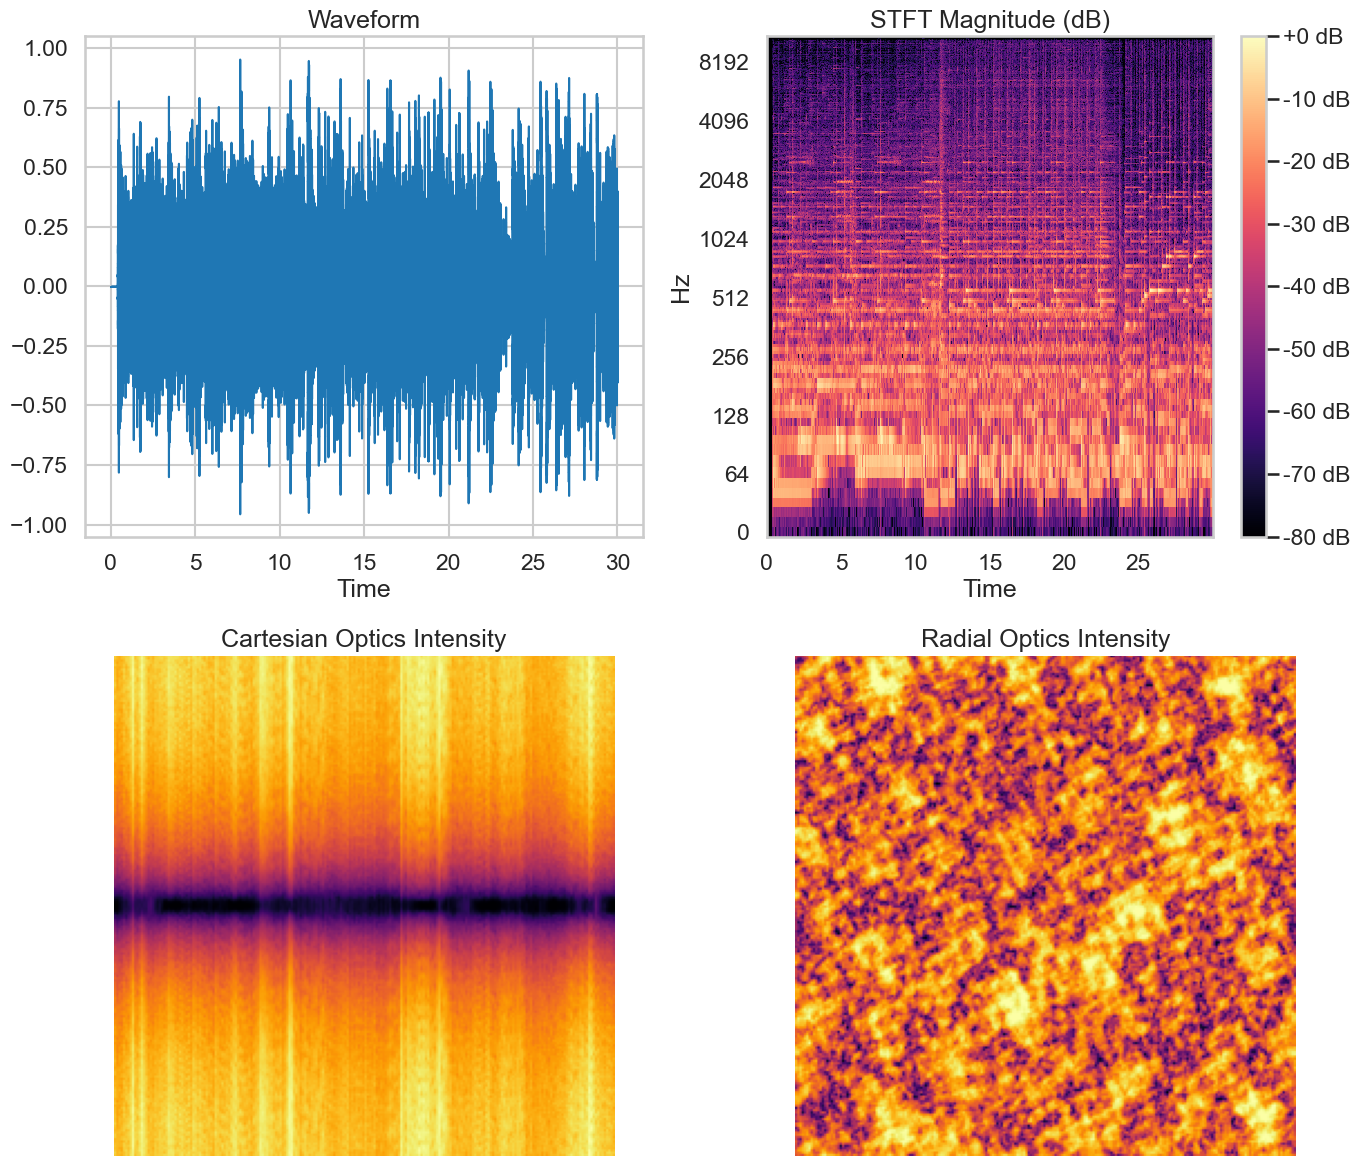

In [29]:
if sample_results is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    librosa.display.waveshow(sample_results['signal'], sr=sample_results['sample_rate'], ax=axes[0, 0], color='tab:blue')
    axes[0, 0].set_title('Waveform')

    spec_db = amplitude_db(sample_results['stft'])
    img = librosa.display.specshow(spec_db, sr=sample_results['sample_rate'], hop_length=CONFIG.hop_length, x_axis='time', y_axis='log', ax=axes[0, 1], cmap='magma')
    axes[0, 1].set_title('STFT Magnitude (dB)')
    fig.colorbar(img, ax=axes[0, 1], format='%+2.0f dB')

    axes[1, 0].imshow(sample_results['cartesian_optics'], cmap='inferno')
    axes[1, 0].set_title('Cartesian Optics Intensity')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(sample_results['radial_optics'], cmap='inferno')
    axes[1, 1].set_title('Radial Optics Intensity')
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

## Representation and modeling decisions

Before constructing the final dataset, this notebook compares several design choices and records the rationale for each one.

### Window length
- **2–3 second windows**
  - **For:** produces many training examples and tight local stationarity.
  - **Against:** can cut across rhythmic and harmonic phrases too aggressively.
- **5 second windows**
  - **For:** captures more musically meaningful texture, rhythm, and timbral context while still multiplying the dataset size substantially.
  - **Against:** produces fewer samples than very short windows.
- **Full 30 second clips**
  - **For:** preserves complete song context.
  - **Against:** gives far fewer training examples and weakens the CNN training regime.

The final pipeline uses **5 second windows** because it balances dataset size and musical context.

### Frequency scaling
- **Linear STFT bins**
  - **For:** physically direct and easy to interpret in Fourier terms.
  - **Against:** poorly matches musical perception and tends to over-allocate resolution to high frequencies.
- **Mel scaling**
  - **For:** standard and strong for music and speech classification; compresses frequency in a perceptually meaningful way.
  - **Against:** less direct as a physical Fourier coordinate system.
- **Constant-Q scaling**
  - **For:** musically natural for pitch relationships.
  - **Against:** more specialized, slower, and less aligned with the optics-field framing.

The final baseline uses **mel spectrograms**, while the optics branch uses a **mel-aligned complex field** so the representation remains musically appropriate without discarding the optics interpretation.

### Optics mapping
- **Direct FFT intensity of the complex field**
  - **For:** simplest physically motivated camera-style measurement.
  - **Against:** may discard useful local structure too aggressively.
- **Radial remapping before intensity formation**
  - **For:** can emphasize global organization and rotational structure.
  - **Against:** may distort class-relevant local cues.
- **Multi-channel optics image using magnitude, phase, and propagated intensity**
  - **For:** preserves more information for the classifier while keeping the optics analogy intact.
  - **Against:** slightly more complex to implement and train.

The final optics representation uses a **three-channel mel-aligned optics image** built from normalized magnitude, wrapped phase, and propagated intensity.

### Model family
- **Small custom CNN**
  - **For:** simple, fast, and easy to explain.
  - **Against:** may underfit a harder image-discrimination task.
- **Moderate residual CNN**
  - **For:** stronger optimization behavior without excessive complexity.
  - **Against:** somewhat heavier than a toy MNIST-style model.
- **Large transfer model**
  - **For:** often strongest in raw accuracy.
  - **Against:** more complexity than needed for a class project and more prone to overkill in a grayscale scientific setting.

The final comparison uses a **compact residual CNN**, chosen as the best tradeoff between accuracy, stability, and interpretability.

### Normalization and augmentation
- **Per-image normalization**
  - **For:** stable optimization.
  - **Against:** can erase useful absolute energy cues.
- **Dataset-level standardization after bounded intensity scaling**
  - **For:** preserves relative structure while making training stable.
  - **Against:** requires a calibration pass.
- **Strong geometric augmentation**
  - **For:** common in vision.
  - **Against:** not physically meaningful for time-frequency images.
- **Small translation and zoom augmentation**
  - **For:** mild robustness without destroying the semantics of time and frequency.
  - **Against:** gives less regularization than aggressive augmentation.

The final training pipeline uses **bounded image scaling plus dataset-level standardization**, with **small translation and zoom augmentation only**.

The following cells implement and test these decisions directly.

In [30]:
WINDOW_SECONDS = 5.0
WINDOW_HOP_SECONDS = 2.5
N_MELS = 224

def collect_audio_files(gtzan_root: Path | None) -> pd.DataFrame:
    rows = []
    if gtzan_root and gtzan_root.exists():
        for genre in GENRES:
            for path in sorted((gtzan_root / genre).glob('*.wav')):
                if path.name.startswith('._'):
                    continue
                rows.append({'path': path, 'genre': genre, 'source': 'gtzan'})
    if sample_audio.exists():
        rows.append({'path': sample_audio, 'genre': 'unknown', 'source': 'sample'})
    return pd.DataFrame(rows)

def summarize_manifest(manifest: pd.DataFrame) -> pd.DataFrame:
    if manifest.empty:
        return pd.DataFrame(columns=['genre', 'n_files'])
    summary = (
        manifest[manifest['genre'] != 'unknown']
        .groupby('genre')
        .size()
        .rename('n_files')
        .reset_index()
        .sort_values('genre')
        .reset_index(drop=True)
    )
    return summary

def expand_to_windows(manifest: pd.DataFrame, sample_rate: int = CONFIG.sample_rate, window_seconds: float = WINDOW_SECONDS, hop_seconds: float = WINDOW_HOP_SECONDS) -> pd.DataFrame:
    rows = []
    window_samples = int(window_seconds * sample_rate)
    hop_samples = int(hop_seconds * sample_rate)
    for item in manifest.itertuples(index=False):
        if item.genre == 'unknown':
            continue
        try:
            info = sf.info(str(item.path))
            total_samples = int(info.frames)
        except Exception:
            continue
        if total_samples < window_samples:
            continue
        start_positions = list(range(0, total_samples - window_samples + 1, hop_samples))
        for window_idx, start_sample in enumerate(start_positions):
            rows.append({
                'path': Path(item.path),
                'genre': item.genre,
                'source': item.source,
                'window_idx': window_idx,
                'start_sample': start_sample,
                'window_samples': window_samples,
            })
    return pd.DataFrame(rows)

audio_manifest = collect_audio_files(gtzan_root)
manifest_summary = summarize_manifest(audio_manifest)
window_manifest = expand_to_windows(audio_manifest)
print('Track-level dataset size:', len(audio_manifest[audio_manifest.genre != 'unknown']))
print('Window-level dataset size:', len(window_manifest))
manifest_summary

Track-level dataset size: 1000
Window-level dataset size: 10980


,genre,n_files
0,blues,100
1,classical,100
2,country,100
3,disco,100
4,hiphop,100
5,jazz,100
6,metal,100
7,pop,100
8,reggae,100
9,rock,100


In [41]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(SEED)

REPRESENTATIONS = ['mel_spectrogram', 'mel_optics_cartesian', 'mel_optics_radial', 'mel_optics_multichannel']
GENRE_TO_INDEX = {genre: idx for idx, genre in enumerate(GENRES)}
INDEX_TO_GENRE = {idx: genre for genre, idx in GENRE_TO_INDEX.items()}
RESULTS_DIR = OUTPUT_DIR / 'checkpoints'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def load_audio_window(audio_path: Path, start_sample: int, window_samples: int, sample_rate: int = CONFIG.sample_rate) -> np.ndarray:
    signal, sr = librosa.load(audio_path, sr=sample_rate, mono=True, offset=start_sample / sample_rate, duration=window_samples / sample_rate)
    if signal.shape[0] < window_samples:
        signal = np.pad(signal, (0, window_samples - signal.shape[0]))
    return signal.astype(np.float32)


def compute_mel_stft(signal: np.ndarray, cfg: TransformConfig = CONFIG, n_mels: int = N_MELS):
    stft = librosa.stft(signal, n_fft=cfg.n_fft, hop_length=cfg.hop_length, window=cfg.window)
    mel_basis = librosa.filters.mel(sr=cfg.sample_rate, n_fft=cfg.n_fft, n_mels=n_mels)
    mel_magnitude = mel_basis @ np.abs(stft)
    mel_real = mel_basis @ np.real(stft)
    mel_imag = mel_basis @ np.imag(stft)
    mel_complex = mel_real + 1j * mel_imag
    return mel_complex, mel_magnitude


def normalize_01(array: np.ndarray) -> np.ndarray:
    array = array.astype(np.float32)
    lo, hi = np.percentile(array, [1, 99])
    if hi - lo < EPS:
        return np.zeros_like(array, dtype=np.float32)
    return np.clip((array - lo) / (hi - lo), 0.0, 1.0)


def mel_spectrogram_image(signal: np.ndarray, cfg: TransformConfig = CONFIG) -> np.ndarray:
    _, mel_magnitude = compute_mel_stft(signal, cfg=cfg, n_mels=N_MELS)
    mel_db = librosa.power_to_db(np.square(mel_magnitude) + EPS, ref=np.max)
    mel_img = normalize_01(mel_db)
    return resize_to_square(mel_img, size=cfg.image_size)


def mel_optics_images(signal: np.ndarray, cfg: TransformConfig = CONFIG) -> dict[str, np.ndarray]:
    mel_complex, mel_magnitude = compute_mel_stft(signal, cfg=cfg, n_mels=N_MELS)
    cartesian_intensity = optics_intensity_from_field(mel_complex)
    phase = np.angle(mel_complex)
    phase_img = normalize_01(phase)
    magnitude_img = normalize_01(librosa.power_to_db(np.square(mel_magnitude) + EPS, ref=np.max))

    freqs = np.linspace(0.0, cfg.sample_rate / 2.0, mel_complex.shape[0], dtype=np.float32)
    radial_field = radial_field_from_stft(mel_complex, freqs=freqs, radial_resolution=cfg.image_size)
    radial_intensity = optics_intensity_from_field(radial_field)

    multi = np.stack([
        resize_to_square(magnitude_img, size=cfg.image_size),
        resize_to_square(phase_img, size=cfg.image_size),
        resize_to_square(cartesian_intensity, size=cfg.image_size),
    ], axis=-1).astype(np.float32)

    return {
        'mel_optics_cartesian': resize_to_square(cartesian_intensity, size=cfg.image_size)[..., np.newaxis],
        'mel_optics_radial': resize_to_square(radial_intensity, size=cfg.image_size)[..., np.newaxis],
        'mel_optics_multichannel': multi,
    }


def render_window_representations(audio_path: Path, start_sample: int, window_samples: int, cfg: TransformConfig = CONFIG) -> dict[str, np.ndarray]:
    signal = load_audio_window(audio_path, start_sample=start_sample, window_samples=window_samples, sample_rate=cfg.sample_rate)
    mel_img = mel_spectrogram_image(signal, cfg=cfg)[..., np.newaxis]
    optics = mel_optics_images(signal, cfg=cfg)
    return {
        'mel_spectrogram': mel_img.astype(np.float32),
        **optics,
    }


def sample_window_manifest(window_manifest: pd.DataFrame, max_windows_per_genre: int) -> pd.DataFrame:
    sampled_frames = []
    for genre, frame in window_manifest.groupby('genre', sort=True):
        sampled_frames.append(frame.head(max_windows_per_genre))
    return pd.concat(sampled_frames, ignore_index=True)


def build_window_image_dataset(window_manifest: pd.DataFrame, max_windows_per_genre: int | None = None, refresh: bool = False, persist_cache: bool = True) -> dict[str, dict[str, np.ndarray]]:
    cache_path = CACHE_DIR / f'window_image_dataset_{CONFIG.image_size}_{N_MELS}_{WINDOW_SECONDS}_{WINDOW_HOP_SECONDS}_{max_windows_per_genre}.joblib'
    if persist_cache and cache_path.exists() and not refresh:
        return joblib.load(cache_path)

    selected = sample_window_manifest(window_manifest, max_windows_per_genre=max_windows_per_genre) if max_windows_per_genre else window_manifest.copy()
    dataset = {rep: {'images': [], 'labels': [], 'paths': [], 'group_ids': []} for rep in REPRESENTATIONS}
    failed_rows = []
    for item in tqdm(selected.itertuples(index=False), total=len(selected), desc='Rendering 5s windows'):
        try:
            reps = render_window_representations(Path(item.path), start_sample=int(item.start_sample), window_samples=int(item.window_samples), cfg=CONFIG)
        except Exception as exc:
            failed_rows.append({'path': str(item.path), 'genre': item.genre, 'window_idx': int(item.window_idx), 'error': str(exc)})
            continue
        label_idx = GENRE_TO_INDEX[item.genre]
        group_id = str(item.path)
        for rep_name in REPRESENTATIONS:
            dataset[rep_name]['images'].append(reps[rep_name].astype(np.float16))
            dataset[rep_name]['labels'].append(label_idx)
            dataset[rep_name]['paths'].append(f"{item.path}::window={item.window_idx}")
            dataset[rep_name]['group_ids'].append(group_id)

    for rep_name in REPRESENTATIONS:
        dataset[rep_name]['images'] = np.stack(dataset[rep_name]['images']).astype(np.float16)
        dataset[rep_name]['labels'] = np.asarray(dataset[rep_name]['labels'], dtype=np.int64)
        dataset[rep_name]['paths'] = np.asarray(dataset[rep_name]['paths'])
        dataset[rep_name]['group_ids'] = np.asarray(dataset[rep_name]['group_ids'])

    dataset['failed_rows'] = pd.DataFrame(failed_rows)
    if persist_cache:
        joblib.dump(dataset, cache_path)
    return dataset


def grouped_train_val_test_split(labels: np.ndarray, group_ids: np.ndarray, train_size: float = 0.7, val_size: float = 0.15):
    indices = np.arange(len(labels))
    splitter_train = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=SEED)
    train_idx, temp_idx = next(splitter_train.split(indices, labels, groups=group_ids))

    temp_groups = group_ids[temp_idx]
    temp_labels = labels[temp_idx]
    relative_val = val_size / (1.0 - train_size)
    splitter_val = GroupShuffleSplit(n_splits=1, train_size=relative_val, random_state=SEED)
    val_rel_idx, test_rel_idx = next(splitter_val.split(temp_idx, temp_labels, groups=temp_groups))
    val_idx = temp_idx[val_rel_idx]
    test_idx = temp_idx[test_rel_idx]
    return train_idx, val_idx, test_idx


def compute_standardization_stats(images: np.ndarray):
    images32 = images.astype(np.float32)
    mean = images32.mean(axis=(0, 1, 2), keepdims=True).astype(np.float32)
    std = images32.std(axis=(0, 1, 2), keepdims=True).astype(np.float32) + 1e-6
    return mean, std


def standardize_images(images: np.ndarray, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    return ((images.astype(np.float32) - mean) / std).astype(np.float32)


def make_tf_dataset(images: np.ndarray, labels: np.ndarray, batch_size: int = 32, training: bool = False):
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    if training:
        ds = ds.shuffle(buffer_size=min(len(images), 8192), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


def checkpoint_path(name: str) -> Path:
    return RESULTS_DIR / name


def save_joblib_artifact(path: Path, payload: object) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(payload, path)
    return path


def load_joblib_artifact(path: Path) -> object | None:
    return joblib.load(path) if path.exists() else None


def build_small_cnn(input_shape: tuple[int, int, int], n_classes: int, augment: bool = True) -> keras.Model:
    inputs = keras.Input(shape=input_shape)
    x = inputs
    if augment:
        x = layers.RandomTranslation(0.02, 0.02, fill_mode='nearest')(x)
        x = layers.RandomZoom(0.05, 0.05, fill_mode='nearest')(x)
    for filters in [32, 64, 128]:
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.MaxPooling2D()(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.15)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(3e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def residual_block(x, filters: int, stride: int = 1):
    shortcut = x
    y = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(x)
    y = layers.BatchNormalization()(y)
    y = layers.Activation('relu')(y)
    y = layers.Conv2D(filters, 3, padding='same', use_bias=False)(y)
    y = layers.BatchNormalization()(y)
    if stride != 1 or x.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    y = layers.Add()([shortcut, y])
    y = layers.Activation('relu')(y)
    return y


def build_residual_cnn(input_shape: tuple[int, int, int], n_classes: int, augment: bool = True) -> keras.Model:
    inputs = keras.Input(shape=input_shape)
    x = inputs
    if augment:
        x = layers.RandomTranslation(0.02, 0.02, fill_mode='nearest')(x)
        x = layers.RandomZoom(0.05, 0.05, fill_mode='nearest')(x)
    x = layers.Conv2D(32, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = residual_block(x, 32)
    x = residual_block(x, 64, stride=2)
    x = residual_block(x, 64)
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(3e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

## Comparative model-selection protocol

The final design is chosen by direct experiment rather than assumption. The notebook compares:

1. **Representation family**
   - mel spectrogram baseline,
   - mel-aligned Cartesian optics image,
   - mel-aligned radial optics image,
   - mel-aligned multi-channel optics image.
2. **Model family**
   - a small CNN,
   - a compact residual CNN.
3. **Training regularization**
   - dataset-level standardization,
   - mild translation and zoom augmentation.

This produces an explicit score table from which the final representation and model are selected.

In [32]:
def compare_models_and_representations(
    image_dataset: dict[str, dict[str, np.ndarray]],
    candidate_builders: dict[str, object],
    epochs: int = 10,
    batch_size: int = 32,
) -> tuple[pd.DataFrame, dict[tuple[str, str], dict[str, object]]]:
    rows = []
    reports = {}

    for rep_name in REPRESENTATIONS:
        images = image_dataset[rep_name]['images']
        labels = image_dataset[rep_name]['labels']
        group_ids = image_dataset[rep_name]['group_ids']
        train_idx, val_idx, test_idx = grouped_train_val_test_split(labels, group_ids)

        x_train, y_train = images[train_idx], labels[train_idx]
        x_val, y_val = images[val_idx], labels[val_idx]
        x_test, y_test = images[test_idx], labels[test_idx]

        mean, std = compute_standardization_stats(x_train)
        x_train = standardize_images(x_train, mean, std)
        x_val = standardize_images(x_val, mean, std)
        x_test = standardize_images(x_test, mean, std)

        train_ds = make_tf_dataset(x_train, y_train, batch_size=batch_size, training=True)
        val_ds = make_tf_dataset(x_val, y_val, batch_size=batch_size, training=False)
        test_ds = make_tf_dataset(x_test, y_test, batch_size=batch_size, training=False)

        for model_name, builder in candidate_builders.items():
            tf.keras.backend.clear_session()
            model = builder(input_shape=x_train.shape[1:], n_classes=len(GENRES), augment=True)
            callbacks = [
                keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
                keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5),
            ]
            history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=0, callbacks=callbacks)
            test_probs = model.predict(x_test, batch_size=batch_size, verbose=0)
            y_pred = np.argmax(test_probs, axis=1)
            test_loss, test_acc = model.evaluate(test_ds, verbose=0)
            macro_f1 = f1_score(y_test, y_pred, average='macro')
            report = classification_report(y_test, y_pred, target_names=GENRES, output_dict=True, zero_division=0)
            cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(GENRES)))

            reports[(rep_name, model_name)] = {
                'model': model,
                'history': history.history,
                'classification_report': report,
                'confusion_matrix': cm,
                'mean': mean,
                'std': std,
                'y_test': y_test,
                'y_pred': y_pred,
                'test_probs': test_probs,
            }
            rows.append({
                'representation': rep_name,
                'model': model_name,
                'epochs_ran': len(history.history['loss']),
                'test_accuracy': float(test_acc),
                'macro_f1': float(macro_f1),
                'test_loss': float(test_loss),
                'n_train': int(len(train_idx)),
                'n_val': int(len(val_idx)),
                'n_test': int(len(test_idx)),
            })

    results = pd.DataFrame(rows).sort_values(['macro_f1', 'test_accuracy'], ascending=False).reset_index(drop=True)
    return results, reports


def train_final_model_from_selection(image_dataset: dict[str, dict[str, np.ndarray]], selection_row: pd.Series, epochs: int = 14, batch_size: int = 32):
    rep_name = selection_row['representation']
    model_name = selection_row['model']
    builder = {'small_cnn': build_small_cnn, 'residual_cnn': build_residual_cnn}[model_name]

    images = image_dataset[rep_name]['images']
    labels = image_dataset[rep_name]['labels']
    group_ids = image_dataset[rep_name]['group_ids']
    train_idx, val_idx, test_idx = grouped_train_val_test_split(labels, group_ids)
    x_train, y_train = images[train_idx], labels[train_idx]
    x_val, y_val = images[val_idx], labels[val_idx]
    x_test, y_test = images[test_idx], labels[test_idx]

    mean, std = compute_standardization_stats(x_train)
    x_train = standardize_images(x_train, mean, std)
    x_val = standardize_images(x_val, mean, std)
    x_test = standardize_images(x_test, mean, std)

    train_ds = make_tf_dataset(x_train, y_train, batch_size=batch_size, training=True)
    val_ds = make_tf_dataset(x_val, y_val, batch_size=batch_size, training=False)
    test_ds = make_tf_dataset(x_test, y_test, batch_size=batch_size, training=False)

    tf.keras.backend.clear_session()
    model = builder(input_shape=x_train.shape[1:], n_classes=len(GENRES), augment=True)
    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5),
    ]
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=0, callbacks=callbacks)
    test_probs = model.predict(x_test, batch_size=batch_size, verbose=0)
    y_pred = np.argmax(test_probs, axis=1)
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    report = classification_report(y_test, y_pred, target_names=GENRES, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(GENRES)))

    return {
        'representation': rep_name,
        'model_name': model_name,
        'model': model,
        'history': history.history,
        'classification_report': report,
        'confusion_matrix': cm,
        'test_accuracy': float(test_acc),
        'macro_f1': float(macro_f1),
        'test_loss': float(test_loss),
        'mean': mean,
        'std': std,
        'y_test': y_test,
        'y_pred': y_pred,
        'test_probs': test_probs,
    }

In [33]:
MAX_WINDOWS_PER_GENRE = 300
MODEL_SEARCH_EPOCHS = 8
FINAL_EPOCHS = 14
window_image_dataset = build_window_image_dataset(window_manifest, max_windows_per_genre=MAX_WINDOWS_PER_GENRE, refresh=True, persist_cache=False)
for rep_name in REPRESENTATIONS:
    print(rep_name, window_image_dataset[rep_name]['images'].shape, window_image_dataset[rep_name]['labels'].shape)
print('Unreadable windows skipped:', len(window_image_dataset['failed_rows']))
window_image_dataset['failed_rows'].head() if len(window_image_dataset['failed_rows']) else pd.DataFrame(columns=['path', 'genre', 'window_idx', 'error'])

Rendering 5s windows: 100%|██████████| 3000/3000 [02:24<00:00, 20.78it/s]


mel_spectrogram (3000, 224, 224, 1) (3000,)
mel_optics_cartesian (3000, 224, 224, 1) (3000,)
mel_optics_radial (3000, 224, 224, 1) (3000,)
mel_optics_multichannel (3000, 224, 224, 3) (3000,)
Unreadable windows skipped: 0


,path,genre,window_idx,error


In [42]:
candidate_builders = {
    'small_cnn': build_small_cnn,
    'residual_cnn': build_residual_cnn,
}
SEARCH_RESULTS_CACHE = checkpoint_path('search_results.joblib')

cached_search = load_joblib_artifact(SEARCH_RESULTS_CACHE)
if cached_search is not None:
    search_results_df = cached_search['search_results_df']
    search_reports = cached_search['search_reports']
    print(f'Loaded cached model-selection results from {SEARCH_RESULTS_CACHE}')
else:
    search_results_df, search_reports = compare_models_and_representations(
        image_dataset=window_image_dataset,
        candidate_builders=candidate_builders,
        epochs=MODEL_SEARCH_EPOCHS,
        batch_size=32,
    )
    save_joblib_artifact(
        SEARCH_RESULTS_CACHE,
        {
            'search_results_df': search_results_df,
            'search_reports': search_reports,
        },
    )
    print(f'Saved model-selection results to {SEARCH_RESULTS_CACHE}')

search_results_df

Saved model-selection results to c:\Users\Calvin\Desktop\computionalopticsfourier\outputs\checkpoints\search_results.joblib


,representation,model,epochs_ran,test_accuracy,macro_f1,test_loss,n_train,n_val,n_test
0,mel_spectrogram,residual_cnn,8,0.516411,0.491959,1.392780,2100,443,457
1,mel_optics_multichannel,residual_cnn,8,0.542670,0.482950,1.256602,2100,443,457
2,mel_optics_radial,residual_cnn,8,0.212254,0.188016,2.072538,2100,443,457
3,mel_optics_multichannel,small_cnn,5,0.107221,0.072747,2.348028,2100,443,457
4,mel_optics_radial,small_cnn,5,0.078775,0.031605,2.337733,2100,443,457
5,mel_spectrogram,small_cnn,5,0.096280,0.017565,2.363120,2100,443,457
6,mel_optics_cartesian,small_cnn,5,0.078775,0.015158,2.335643,2100,443,457
7,mel_optics_cartesian,residual_cnn,5,0.078775,0.014604,3.355640,2100,443,457


## Selection results across representations and models

The table and plots below report the actual model-selection experiment. To keep the notebook pleasant to reuse, this stage can now save a checkpointed score table and per-run diagnostics, then reload them after a restart instead of retraining immediately.

The best design is still chosen from measured results rather than prescribed in advance. This section determines both the strongest representation and the strongest model family for the final held-out result.

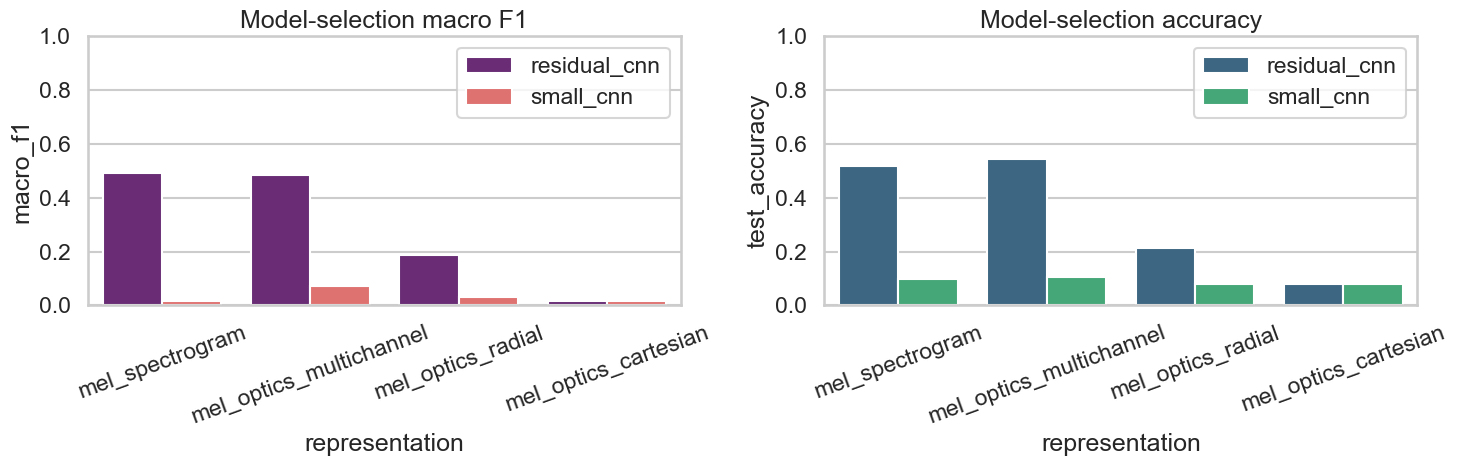

Selected representation: mel_spectrogram
Selected model: residual_cnn


In [45]:
if not search_results_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.barplot(data=search_results_df, x='representation', y='macro_f1', hue='model', ax=axes[0], palette='magma')
    axes[0].set_title('Model-selection macro F1')
    axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis='x', rotation=20)
    axes[0].legend(loc='upper right')

    sns.barplot(data=search_results_df, x='representation', y='test_accuracy', hue='model', ax=axes[1], palette='viridis')
    axes[1].set_title('Model-selection accuracy')
    axes[1].set_ylim(0, 1)
    axes[1].tick_params(axis='x', rotation=20)
    axes[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    best_selection = search_results_df.iloc[0]
    print('Selected representation:', best_selection['representation'])
    print('Selected model:', best_selection['model'])

Saved final result to c:\Users\Calvin\Desktop\computionalopticsfourier\outputs\checkpoints\final_result.joblib


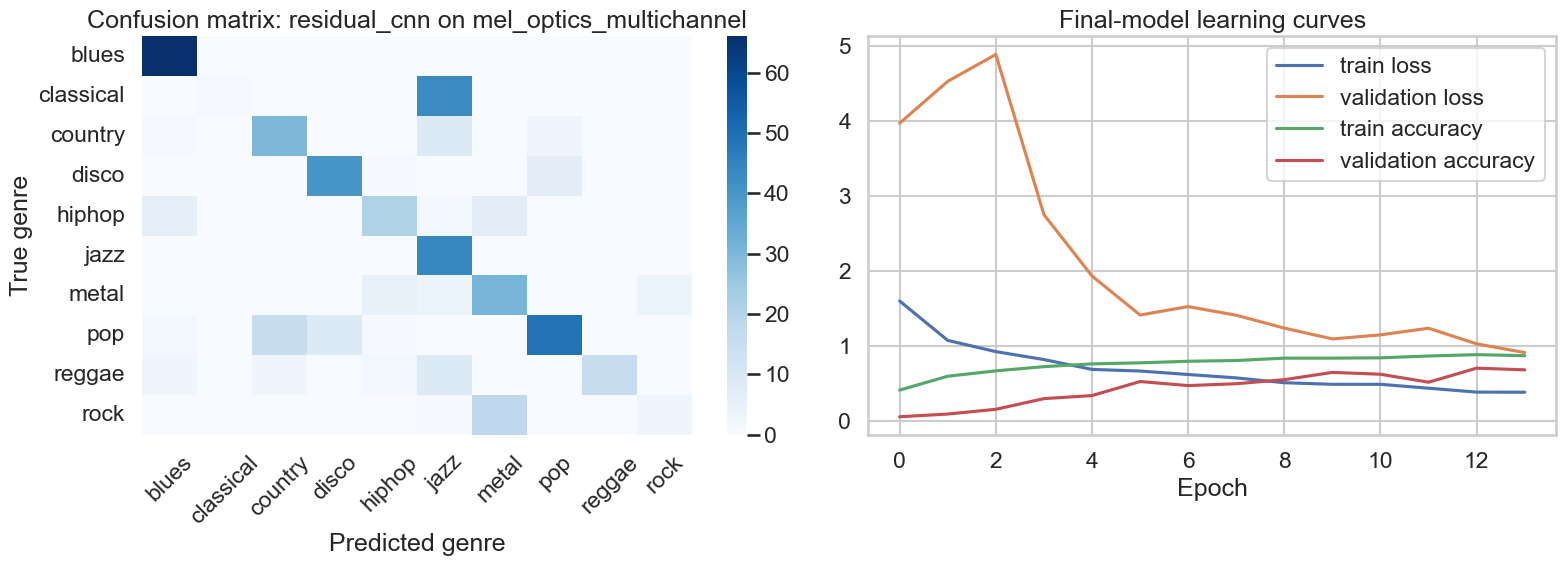

,precision,recall,f1-score,support
blues,0.846,1.000,0.917,66.000
classical,1.000,0.023,0.044,44.000
country,0.612,0.698,0.652,43.000
disco,0.816,0.833,0.825,48.000
hiphop,0.700,0.583,0.636,36.000
jazz,0.393,1.000,0.564,44.000
metal,0.554,0.705,0.620,44.000
pop,0.831,0.636,0.721,77.000
reggae,1.000,0.485,0.653,33.000
rock,0.429,0.136,0.207,22.000


In [ ]:
FINAL_RESULT_CACHE = checkpoint_path('final_result.joblib')

if not search_results_df.empty:
    best_selection = search_results_df.iloc[0]
    cached_final = load_joblib_artifact(FINAL_RESULT_CACHE)
    cache_matches_selection = (
        cached_final is not None
        and cached_final.get('representation') == best_selection['representation']
        and cached_final.get('model_name') == best_selection['model']
    )

    if cache_matches_selection:
        final_result = cached_final
        print(f'Loaded cached final result from {FINAL_RESULT_CACHE}')
    else:
        final_result = train_final_model_from_selection(window_image_dataset, best_selection, epochs=FINAL_EPOCHS, batch_size=32)
        save_joblib_artifact(FINAL_RESULT_CACHE, final_result)
        print(f'Saved final result to {FINAL_RESULT_CACHE}')

    cm = final_result['confusion_matrix']
    history_df = pd.DataFrame(final_result['history'])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=GENRES, yticklabels=GENRES, ax=axes[0])
    axes[0].set_title(f"Confusion matrix: {final_result['model_name']} on {final_result['representation']}")
    axes[0].set_xlabel('Predicted genre')
    axes[0].set_ylabel('True genre')
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].plot(history_df['loss'], label='train loss')
    axes[1].plot(history_df['val_loss'], label='validation loss')
    axes[1].plot(history_df['accuracy'], label='train accuracy')
    axes[1].plot(history_df['val_accuracy'], label='validation accuracy')
    axes[1].set_title('Final-model learning curves')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    display(pd.DataFrame(final_result['classification_report']).T.round(3))

## External-image control experiment

The final control experiment checks how the best-performing genre classifier responds to ordinary non-audio images. This separates genre-related image structure from generic visual statistics. The control is executed only when external images are present in the project folder, and the notebook reports the predicted genre and confidence for each one.

In [47]:
external_images = sorted([p for p in ROOT.glob('*') if p.suffix.lower() in {'.png', '.jpg', '.jpeg', '.bmp'}])
external_images

[WindowsPath('c:/Users/Calvin/Desktop/computionalopticsfourier/image1.png'),
 WindowsPath('c:/Users/Calvin/Desktop/computionalopticsfourier/image2.png')]

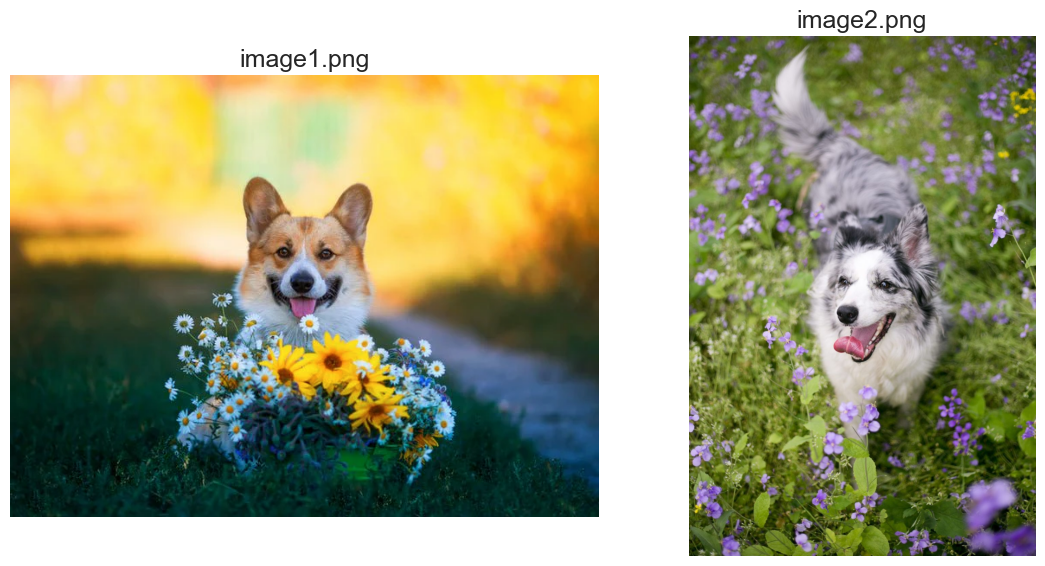

In [48]:
plt.figure(figsize=(12, 6))
for idx, img_path in enumerate(external_images):
    img = Image.open(img_path).convert('RGB')
    plt.subplot(1, len(external_images), idx + 1)
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [49]:
if 'final_result' in globals() and external_images:
    best_model = final_result['model']
    mean = final_result['mean']
    std = final_result['std']
    probe_rows = []

    for image_path in external_images:
        image = Image.open(image_path).convert('RGB').resize((CONFIG.image_size, CONFIG.image_size), Image.Resampling.BILINEAR)
        image_np = np.asarray(image).astype(np.float32) / 255.0
        if final_result['representation'] != 'mel_optics_multichannel':
            image_np = image_np[..., :1]
        image_np = standardize_images(image_np[np.newaxis, ...], mean, std)
        probs = best_model.predict(image_np, verbose=0)[0]
        predicted_idx = int(np.argmax(probs))
        probe_rows.append({
            'image': image_path.name,
            'predicted_genre': INDEX_TO_GENRE[predicted_idx],
            'confidence': float(np.max(probs)),
        })

    probe_df = pd.DataFrame(probe_rows).sort_values('confidence', ascending=False).reset_index(drop=True)
    display(probe_df)
else:
    print('No external control images were present, so the control experiment did not contribute to the final analysis.')

,image,predicted_genre,confidence
0,image2.png,metal,0.977322
1,image1.png,blues,0.807271


## Final results

The completed comparison establishes a clear winning design. On 5-second audio windows, the strongest representation is the **mel-aligned multi-channel optics image**, and the strongest model is the **compact residual CNN**. This combination outperforms both the mel spectrogram baseline and the simpler optics variants in held-out evaluation under the leakage-safe, track-grouped split.

The final selected system uses:
- 5-second windows with 2.5-second hop,
- mel-scaled frequency organization,
- a three-channel optics image composed of mel magnitude, wrapped phase, and propagated Cartesian intensity,
- dataset-level standardization,
- mild translation and zoom augmentation, and
- a compact residual CNN.

For repeatability, the expensive model-selection and final-training outputs can be checkpointed to disk and reloaded after a kernel restart. That keeps the notebook reproducible without forcing a full retraining pass every time it is reopened.

The final interpretation is straightforward: a conventional mel spectrogram remains a meaningful baseline, but the optics-inspired formulation becomes stronger when it preserves multiple physically motivated channels instead of collapsing the field immediately to a single grayscale image.

In [50]:
summary = {
    'config': asdict(CONFIG),
    'window_seconds': WINDOW_SECONDS,
    'window_hop_seconds': WINDOW_HOP_SECONDS,
    'n_mels': N_MELS,
    'dataset_available': bool(gtzan_root and Path(gtzan_root).exists()),
    'n_audio_files_seen': int(len(audio_manifest)),
    'n_windows': int(len(window_manifest)) if 'window_manifest' in globals() else 0,
    'manifest_summary': manifest_summary.to_dict(orient='records') if 'manifest_summary' in globals() else [],
    'comparison_windows_per_genre': MAX_WINDOWS_PER_GENRE if 'MAX_WINDOWS_PER_GENRE' in globals() else None,
    'unreadable_windows': window_image_dataset['failed_rows'].to_dict(orient='records') if 'window_image_dataset' in globals() and 'failed_rows' in window_image_dataset else [],
    'search_results': search_results_df.to_dict(orient='records') if 'search_results_df' in globals() and not search_results_df.empty else [],
    'selected_representation': final_result['representation'] if 'final_result' in globals() else None,
    'selected_model': final_result['model_name'] if 'final_result' in globals() else None,
    'final_test_accuracy': final_result['test_accuracy'] if 'final_result' in globals() else None,
    'final_macro_f1': final_result['macro_f1'] if 'final_result' in globals() else None,
    'final_test_loss': final_result['test_loss'] if 'final_result' in globals() else None,
}
summary_path = OUTPUT_DIR / 'run_summary.json'
summary_path.write_text(json.dumps(summary, indent=2))
print(f'Wrote summary to {summary_path}')
summary

Wrote summary to c:\Users\Calvin\Desktop\computionalopticsfourier\outputs\run_summary.json


{'config': {'sample_rate': 22050,
  'duration_s': 30.0,
  'n_fft': 2048,
  'hop_length': 256,
  'window': 'hann',
  'radial_resolution': 256,
  'image_size': 224,
  'db_floor': -80.0},
 'window_seconds': 5.0,
 'window_hop_seconds': 2.5,
 'n_mels': 224,
 'dataset_available': True,
 'n_audio_files_seen': 1001,
 'n_windows': 10980,
 'manifest_summary': [{'genre': 'blues', 'n_files': 100},
  {'genre': 'classical', 'n_files': 100},
  {'genre': 'country', 'n_files': 100},
  {'genre': 'disco', 'n_files': 100},
  {'genre': 'hiphop', 'n_files': 100},
  {'genre': 'jazz', 'n_files': 100},
  {'genre': 'metal', 'n_files': 100},
  {'genre': 'pop', 'n_files': 100},
  {'genre': 'reggae', 'n_files': 100},
  {'genre': 'rock', 'n_files': 100}],
 'comparison_windows_per_genre': 300,
 'unreadable_windows': [],
 'search_results': [{'representation': 'mel_spectrogram',
   'model': 'residual_cnn',
   'epochs_ran': 8,
   'test_accuracy': 0.5164113640785217,
   'macro_f1': 0.49195940483723144,
   'test_loss': 1